### Quals Paper Figures 

In [2]:
# imports 
# import packages 
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from scipy import signal, interpolate
import gsw
import cmocean
from TNB_tools import trough_cross_section
import matplotlib.ticker as mticker

In [11]:
# set font size parameters 
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.title_fontsize': 10,
    'font.family': 'sans-serif',   # or 'serif' if the journal wants Times-like fonts
})

### Study Site Map 

In [3]:
# load bathymetry data 

bath = xr.open_dataset('BedMachine_TNB_subset.nc')


# load mooring data 
# LOAD IN SAVED INTERMEDIATE FILES - MAC 

TNBD_ctd_top = xr.open_dataset('data/TNBD_ctd_top_30min.nc')
TNBD_ctd_bot = xr.open_dataset('data/TNBD_ctd_bot_30min.nc')
TNBD_vel_top = xr.open_dataset('data/TNBD_vel_top_30min.nc')
TNBD_vel_bot = xr.open_dataset('data/TNBD_vel_bot_30min.nc')

DITD_ctd_top = xr.open_dataset('data/DITD_ctd_top_30min.nc')
DITD_ctd_bot = xr.open_dataset('data/DITD_ctd_bot_30min.nc')
DITD_vel_top = xr.open_dataset('data/DITD_vel_top_30min.nc')
DITD_vel_bot = xr.open_dataset('data/DITD_vel_bot_30min.nc')      # sensor cut out in june 2018

D_ctd_top = xr.open_dataset('data/D_ctd_top_30min.nc')
D_ctd_mid = xr.open_dataset('data/D_ctd_mid_30min.nc')
# D_ctd_bot = D_ctd_bot.sel(time=time_slice).resample(time=resample).mean()        # this sensor cut out in 2017

# D_vel_top = D_vel_top.sel(time=time_slice).resample(time=resample).mean()        # this sensor cut out end of 2017
D_vel_mid = xr.open_dataset('data/D_vel_mid_30min.nc')
D_vel_bot = xr.open_dataset('data/D_vel_bot_30min.nc')

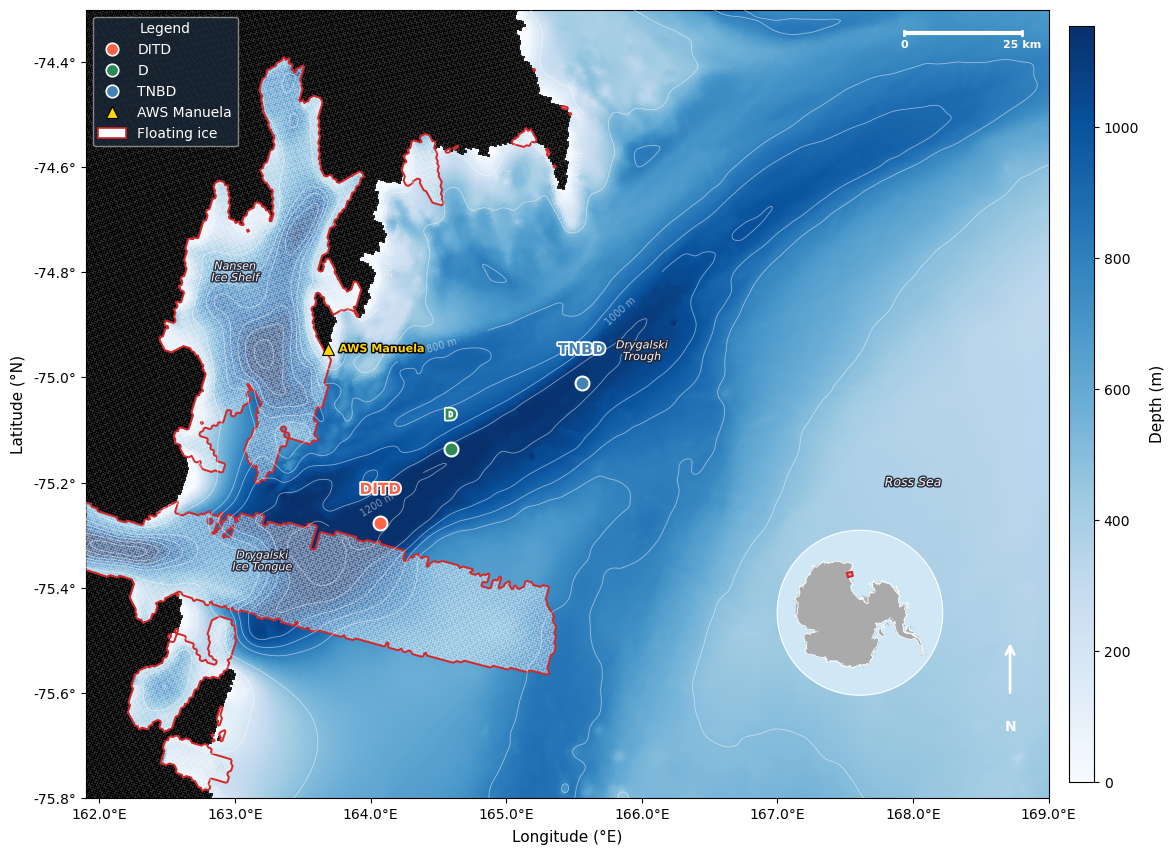

In [4]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter
from pyproj import Transformer
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath

# ── USER INPUTS ───────────────────────────────────────────────────────────────
MOORINGS = {
    'DITD': {
        'lon':    float(DITD_ctd_top.lon.values),
        'lat':    float(DITD_ctd_top.lat.values),
        'color':  'tomato',
        'vel_ds': DITD_vel_top,
    },
    'D': {
        'lon':    float(D_vel_bot.lon.values),
        'lat':    float(D_vel_bot.lat.values),
        'color':  'seagreen',
        'vel_ds': D_vel_bot,
    },
    'TNBD': {
        'lon':    float(TNBD_vel_bot.lon.values),
        'lat':    float(TNBD_vel_bot.lat.values),
        'color':  'steelblue',
        'vel_ds': TNBD_vel_bot,
    },
}

AWS_MANUELA = {'lon': 163.687, 'lat': -74.946}

LON_BOUNDS     = (161.9, 169.0)
LAT_BOUNDS     = (-75.8, -74.3)
DEPTH_CONTOURS = [200, 500, 800, 900, 1000, 1100, 1200]
QUIVER_SCALE   = 0.07
ARROW_REF_SPEED = 0.05

# Geographic labels — adjust positions to suit your map
GEO_LABELS = [
    {'text': 'Drygalski\nIce Tongue', 'lon': 163.2,  'lat': -75.35,
     'size': 8,  'style': 'italic', 'color': 'white'},
    {'text': 'Nansen\nIce Shelf',     'lon': 163,  'lat': -74.8,
     'size': 8,  'style': 'italic', 'color': 'white'},
    # {'text': 'Terra Nova\nBay',       'lon': 165.5,  'lat': -74.65,
    #  'size': 9,  'style': 'italic', 'color': 'white'},
    {'text': 'Drygalski\nTrough',     'lon': 166,  'lat': -74.95,
     'size': 8,  'style': 'italic', 'color': 'white'},
    {'text': 'Ross Sea',              'lon': 168,  'lat': -75.2,
     'size': 9,  'style': 'italic', 'color': 'white'},
]

# ── LOAD BEDMACHINE ───────────────────────────────────────────────────────────
transformer_inv = Transformer.from_crs('EPSG:3031', 'EPSG:4326',
                                        always_xy=True)
x_2d, y_2d     = np.meshgrid(bath['x'].values, bath['y'].values)
lon_2d, lat_2d = transformer_inv.transform(x_2d, y_2d)

bed  = bath['bed'].values.astype(float)
mask = bath['mask'].values

depth_raw  = np.where(bed < 0, -bed, np.nan)
ocean_mask = (mask == 0) | (mask == 3)
depth_plot = np.where(ocean_mask, depth_raw, np.nan)
depth_sm   = gaussian_filter(np.where(ocean_mask, depth_raw, 0), sigma=2)
depth_sm   = np.where(ocean_mask, depth_sm, np.nan)

in_bounds      = ((lon_2d >= LON_BOUNDS[0]) & (lon_2d <= LON_BOUNDS[1]) &
                   (lat_2d >= LAT_BOUNDS[0]) & (lat_2d <= LAT_BOUNDS[1]))
depth_inbounds = depth_plot[in_bounds & np.isfinite(depth_plot)]
vmax           = np.nanpercentile(depth_inbounds, 98) \
                 if depth_inbounds.size > 0 else 2000

# ── COMPUTE RECORD MEAN VELOCITIES ────────────────────────────────────────────
# lat_mean  = np.mean(LAT_BOUNDS)
# lat_scale = np.cos(np.deg2rad(lat_mean))

# for name, props in MOORINGS.items():
#     ds_vel          = props['vel_ds']
#     u_mean          = float(np.nanmean(ds_vel['u'].values))
#     v_mean          = float(np.nanmean(ds_vel['v'].values))
#     props['u_mean'] = u_mean
#     props['v_mean'] = v_mean
#     props['speed']  = np.sqrt(u_mean**2 + v_mean**2)

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 11))
fig.patch.set_facecolor('white')

# ── Bathymetry ────────────────────────────────────────────────────────────────
pcm = ax.pcolormesh(lon_2d, lat_2d, depth_plot,
                     cmap='Blues', shading='auto',
                     vmin=0, vmax=vmax, zorder=1)
cbar = plt.colorbar(pcm, ax=ax, pad=0.02, fraction=0.025, aspect=30)
cbar.set_label('Depth (m)', fontsize=11, labelpad=8)
cbar.ax.tick_params(labelsize=10)

# ── Land / grounded ice ───────────────────────────────────────────────────────
land = np.where((mask == 1) | (mask == 2), 1.0, np.nan)
ax.pcolormesh(lon_2d, lat_2d, land,
              cmap='Greys', shading='auto',
              vmin=0, vmax=1, alpha=0.85, zorder=2)

# ── Floating ice — translucent white + tab:red outline ───────────────────────
floating_white = np.where(mask == 3, 1.0, np.nan)
ax.pcolormesh(lon_2d, lat_2d, floating_white,
              cmap='Greys_r', shading='auto',
              vmin=0, vmax=1, alpha=0.3, zorder=3)

ax.contour(lon_2d, lat_2d, (mask == 3).astype(float),
           levels=[0.5],
           colors=['tab:red'],
           linewidths=1.4,
           linestyles='-',
           zorder=5)

# ── Isobath contours ──────────────────────────────────────────────────────────
valid_contours = [c for c in DEPTH_CONTOURS
                  if np.nanmin(depth_sm) < c < np.nanmax(depth_sm)]
if valid_contours:
    cs = ax.contour(lon_2d, lat_2d, depth_sm,
                     levels=valid_contours,
                     colors='white', linewidths=0.6,
                     alpha=0.5, zorder=6)
    ax.clabel(cs, levels=valid_contours[::2], fmt='%d m',
              fontsize=7, colors='white', inline=True,
              inline_spacing=4)

# ── Geographic labels ─────────────────────────────────────────────────────────
for lbl in GEO_LABELS:
    t = ax.text(lbl['lon'], lbl['lat'], lbl['text'],
                ha='center', va='center',
                fontsize=lbl['size'], style=lbl['style'],
                color=lbl['color'], zorder=7, alpha=0.95)
    t.set_path_effects([
        pe.withStroke(linewidth=2.0, foreground='#222233')])

# ── Mooring markers ───────────────────────────────────────────────────────────
for name, props in MOORINGS.items():
    ax.plot(props['lon'], props['lat'],
            marker='o', markersize=10, color=props['color'],
            markeredgecolor='white', markeredgewidth=1.5,
            linestyle='none', zorder=9)

        # ← uncomment these lines
    txt = ax.text(props['lon'], props['lat'] + 0.05, name,
                  ha='center', va='bottom', fontsize=11,
                  fontweight='bold', color=props['color'], zorder=9)
    txt.set_path_effects([
        pe.withStroke(linewidth=2.5, foreground='white')])

# ── AWS Manuela marker ────────────────────────────────────────────────────────
ax.plot(AWS_MANUELA['lon'], AWS_MANUELA['lat'],
        marker='^', markersize=9, color='gold',
        markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=9,
        label='AWS Manuela')
txt = ax.text(AWS_MANUELA['lon'] + 0.08, AWS_MANUELA['lat'],
              'AWS Manuela',
              ha='left', va='center', fontsize=8,
              color='gold', fontweight='bold', zorder=10)
txt.set_path_effects([pe.withStroke(linewidth=2.0, foreground='k')])

# ── Current vectors ───────────────────────────────────────────────────────────
# for name, props in MOORINGS.items():
#     qv = ax.quiver(
#         props['lon'], props['lat'],
#         props['u_mean'], props['v_mean'],
#         color=props['color'],
#         scale=QUIVER_SCALE,
#         scale_units='inches',
#         width=0.005,
#         headwidth=4,
#         headlength=5,
#         headaxislength=4.5,
#         zorder=10,
#     )

# ax.quiverkey(qv, X=0.80, Y=0.06,
#               U=ARROW_REF_SPEED,
#               label=f'{ARROW_REF_SPEED} m/s',
#               labelpos='E',
#               fontproperties={'size': 9},
#               color='white',
#               labelcolor='white',
#               zorder=11)

# ── North arrow ───────────────────────────────────────────────────────────────
ax.annotate('', xy=(0.96, 0.20), xytext=(0.96, 0.13),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='white',
                            lw=2.0, mutation_scale=15))
ax.text(0.96, 0.10, 'N', transform=ax.transAxes,
        ha='center', va='top', fontsize=10,
        color='white', fontweight='bold')

# ── Legend ────────────────────────────────────────────────────────────────────
ice_patch = mpatches.Patch(facecolor='white', edgecolor='tab:red',
                            linewidth=1.2, label='Floating ice')
aws_handle = plt.Line2D([0], [0], marker='^', color='none',
                         markerfacecolor='gold', markeredgecolor='k',
                         markeredgewidth=0.8, markersize=9,
                         label='AWS Manuela')
mooring_handles = [
    plt.Line2D([0], [0], marker='o', color='none',
               markerfacecolor=p['color'],
               markeredgecolor='white',
               markeredgewidth=1.2,
               markersize=9, label=n)
    for n, p in MOORINGS.items()
]

leg = ax.legend(handles=mooring_handles + [aws_handle, ice_patch],
                loc='upper left', fontsize=10,
                framealpha=0.75, edgecolor='#aaaaaa',
                facecolor='#1a2a3a', labelcolor='white',
                title='Legend', title_fontsize=10)
leg.get_title().set_color('white')

# ── Axes formatting ───────────────────────────────────────────────────────────
lat_mean = np.mean(LAT_BOUNDS)
ax.set_aspect(1.0 / np.cos(np.deg2rad(lat_mean)))
ax.set_xlim(LON_BOUNDS)
ax.set_ylim(LAT_BOUNDS)
ax.set_xlabel('Longitude (°E)', fontsize=11, labelpad=6)
ax.set_ylabel('Latitude (°N)',  fontsize=11, labelpad=6)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}°E'))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f'{y:.1f}°'))
ax.tick_params(labelsize=10)

# ── Scale bar ─────────────────────────────────────────────────────────────────
R          = 6371.0
km_per_deg = R * np.cos(np.deg2rad(lat_mean)) * np.pi / 180.0
bar_deg    = 25 / km_per_deg   # ← 25 km instead of 50
xlim, ylim = ax.get_xlim(), ax.get_ylim()

# Top right — offset inward from the right and top edges
sb_x = xlim[1] - 0.15 * (xlim[1] - xlim[0])   # 22% from right edge
sb_y = ylim[1] - 0.03 * (ylim[1] - ylim[0])   # 6% from top edge

ax.plot([sb_x, sb_x + bar_deg], [sb_y, sb_y],
        color='white', lw=3, solid_capstyle='butt', zorder=12)
for xpt in [sb_x, sb_x + bar_deg]:
    ax.plot([xpt, xpt], [sb_y - 0.004, sb_y + 0.004],
            color='white', lw=2, zorder=12)
ax.text(sb_x,             sb_y - 0.012, '0',
        ha='center', va='top', fontsize=8,
        color='white', fontweight='bold', zorder=12)
ax.text(sb_x + bar_deg,   sb_y - 0.012, '25 km',
        ha='center', va='top', fontsize=8,
        color='white', fontweight='bold', zorder=12)

# ── INSET MAP ────────────────────────────────────────────────────────────────
ax_inset = fig.add_axes([0.65, 0.25, 0.15, 0.15],
                          projection=ccrs.SouthPolarStereo(central_longitude=180))
ax_inset.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax_inset.add_feature(cfeature.LAND,  facecolor='#aaaaaa', zorder=1)
ax_inset.add_feature(cfeature.OCEAN, facecolor='#d0e8f5', zorder=0)
ax_inset.coastlines(resolution='110m', color='white',
                    linewidth=0.6, zorder=2)

study_lons = [LON_BOUNDS[0], LON_BOUNDS[1],
              LON_BOUNDS[1], LON_BOUNDS[0], LON_BOUNDS[0]]
study_lats = [LAT_BOUNDS[0], LAT_BOUNDS[0],
              LAT_BOUNDS[1], LAT_BOUNDS[1], LAT_BOUNDS[0]]
ax_inset.plot(study_lons, study_lats,
              color='tab:red', lw=1.5,
              transform=ccrs.PlateCarree(), zorder=3)
ax_inset.fill(study_lons, study_lats,
              color='tab:red', alpha=0.3,
              transform=ccrs.PlateCarree(), zorder=3)

theta  = np.linspace(0, 2 * np.pi, 100)
center = [0.5, 0.5]
radius = 0.5
verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax_inset.set_boundary(circle, transform=ax_inset.transAxes)

for spine in ax_inset.spines.values():
    spine.set_edgecolor('white')
    spine.set_linewidth(0.8)

plt.subplots_adjust(left=0.08, right=0.92, top=0.95, bottom=0.08)
# plt.savefig('study_site_bedmachine.png',
#             dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

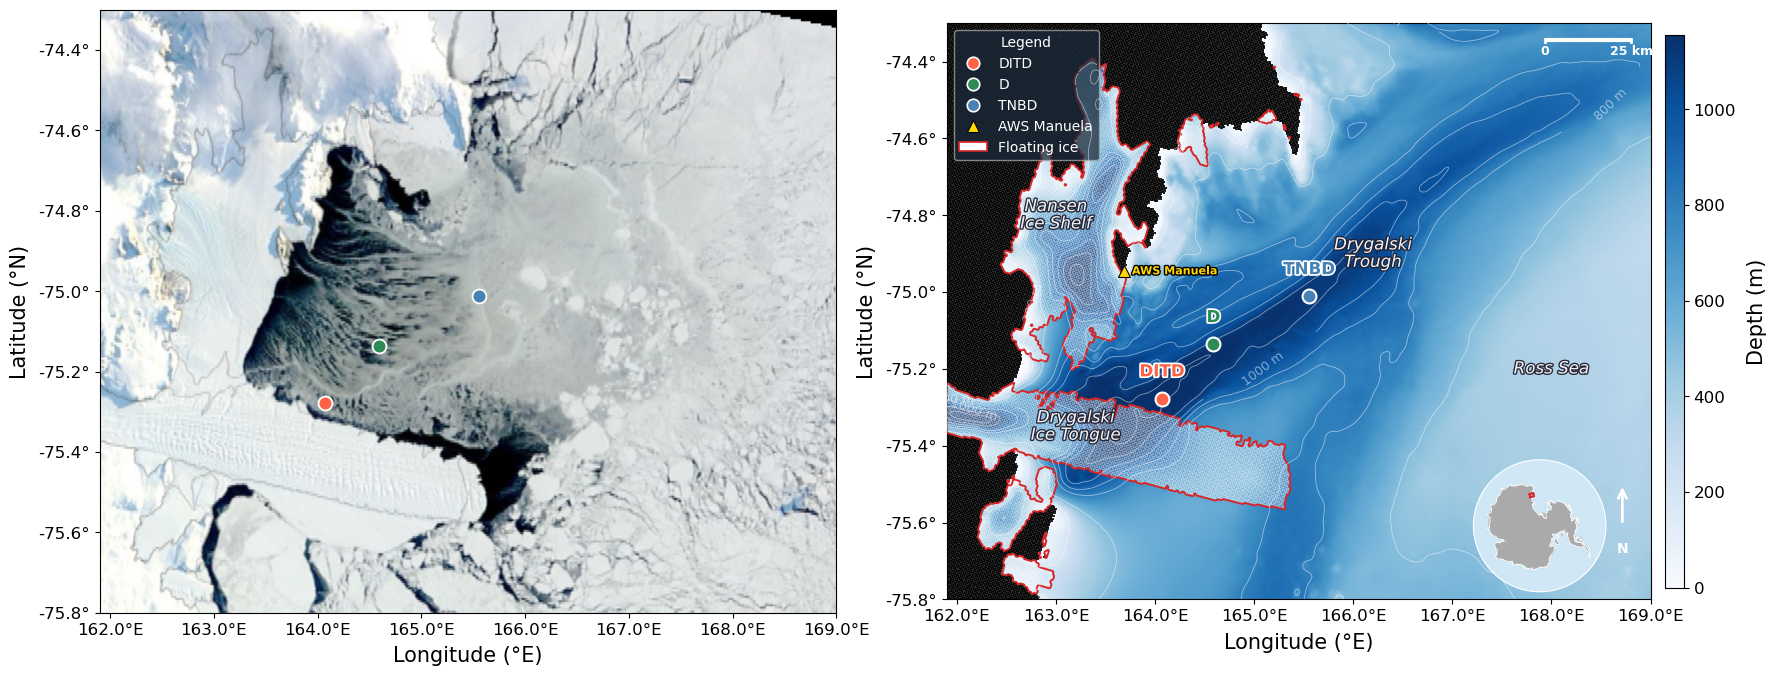

In [34]:
import numpy as np
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter
from pyproj import Transformer
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath

plt.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 14,
    'axes.titlesize': 10,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 10,
})
FIGSIZE = (18, 11)

# ── USER INPUTS ───────────────────────────────────────────────────────────────
MOORINGS = {
    'DITD': {
        'lon':    float(DITD_ctd_top.lon.values),
        'lat':    float(DITD_ctd_top.lat.values),
        'color':  'tomato',
        'vel_ds': DITD_vel_top,
    },
    'D': {
        'lon':    float(D_vel_bot.lon.values),
        'lat':    float(D_vel_bot.lat.values),
        'color':  'seagreen',
        'vel_ds': D_vel_bot,
    },
    'TNBD': {
        'lon':    float(TNBD_vel_bot.lon.values),
        'lat':    float(TNBD_vel_bot.lat.values),
        'color':  'steelblue',
        'vel_ds': TNBD_vel_bot,
    },
}

AWS_MANUELA = {'lon': 163.687, 'lat': -74.946}

LON_BOUNDS     = (161.9, 169.0)
LAT_BOUNDS     = (-75.8, -74.3)
DEPTH_CONTOURS = [200, 500, 800, 900, 1000, 1100, 1200]
QUIVER_SCALE   = 0.07
ARROW_REF_SPEED = 0.05

SATELLITE_TIF = "/Users/mblan/Downloads/snapshot-2018-03-23_TNB.tiff"   # ← path to your NASA Worldview GeoTIFF download

# Geographic labels — adjust positions to suit your map
GEO_LABELS = [
    {'text': 'Drygalski\nIce Tongue', 'lon': 163.2,  'lat': -75.35,
     'size': 12,  'style': 'italic', 'color': 'white'},
    {'text': 'Nansen\nIce Shelf',     'lon': 163,  'lat': -74.8,
     'size': 12,  'style': 'italic', 'color': 'white'},
    {'text': 'Drygalski\nTrough',     'lon': 166.2,  'lat': -74.9,
     'size': 12,  'style': 'italic', 'color': 'white'},
    {'text': 'Ross Sea',              'lon': 168,  'lat': -75.2,
     'size': 12,  'style': 'italic', 'color': 'white'},
]

lat_mean  = np.mean(LAT_BOUNDS)
lat_scale = 1.0 / np.cos(np.deg2rad(lat_mean))

# ── LOAD BEDMACHINE ───────────────────────────────────────────────────────────
transformer_inv = Transformer.from_crs('EPSG:3031', 'EPSG:4326',
                                        always_xy=True)
x_2d, y_2d     = np.meshgrid(bath['x'].values, bath['y'].values)
lon_2d, lat_2d = transformer_inv.transform(x_2d, y_2d)

bed  = bath['bed'].values.astype(float)
mask = bath['mask'].values

depth_raw  = np.where(bed < 0, -bed, np.nan)
ocean_mask = (mask == 0) | (mask == 3)
depth_plot = np.where(ocean_mask, depth_raw, np.nan)
depth_sm   = gaussian_filter(np.where(ocean_mask, depth_raw, 0), sigma=2)
depth_sm   = np.where(ocean_mask, depth_sm, np.nan)

in_bounds      = ((lon_2d >= LON_BOUNDS[0]) & (lon_2d <= LON_BOUNDS[1]) &
                   (lat_2d >= LAT_BOUNDS[0]) & (lat_2d <= LAT_BOUNDS[1]))
depth_inbounds = depth_plot[in_bounds & np.isfinite(depth_plot)]
vmax           = np.nanpercentile(depth_inbounds, 98) \
                 if depth_inbounds.size > 0 else 2000

# ── FIGURE: TWO PANELS ─────────────────────────────────────────────────────────
fig, (ax_sat, ax) = plt.subplots(1, 2, figsize=FIGSIZE)
fig.patch.set_facecolor('white')

# ═══════════════════════════════════════════════════════════════════════════
# LEFT PANEL — satellite image
# ═══════════════════════════════════════════════════════════════════════════
with rasterio.open(SATELLITE_TIF) as src:
    sat_img = src.read()
    sat_bounds = src.bounds
    sat_crs = src.crs
    # Reproject to EPSG:4326 if needed
    if sat_crs is not None and sat_crs.to_epsg() != 4326:
        from rasterio.warp import calculate_default_transform, reproject, Resampling
        dst_crs = 'EPSG:4326'
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        sat_img_reproj = np.empty((src.count, height, width), dtype=src.dtypes[0])
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=sat_img_reproj[i - 1],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear)
        sat_img = sat_img_reproj
        sat_extent = [transform[2], transform[2] + transform[0] * width,
                      transform[5] + transform[4] * height, transform[5]]
    else:
        sat_extent = [sat_bounds.left, sat_bounds.right,
                      sat_bounds.bottom, sat_bounds.top]

# imshow expects (rows, cols, bands); rasterio reads as (bands, rows, cols)
sat_display = np.transpose(sat_img[:3], (1, 2, 0))  # first 3 bands as RGB
# Normalize to 0-1 if needed (uint16 or reflectance data)
if sat_display.dtype != np.uint8:
    sat_display = sat_display.astype(float)
    p2, p98 = np.nanpercentile(sat_display, (2, 98))
    sat_display = np.clip((sat_display - p2) / (p98 - p2), 0, 1)

ax_sat.imshow(sat_display, extent=sat_extent, origin='upper', zorder=1)

ax_sat.set_xlim(LON_BOUNDS)
ax_sat.set_ylim(LAT_BOUNDS)
ax_sat.set_aspect(lat_scale)
ax_sat.set_xlabel('Longitude (°E)', fontsize=15, labelpad=6)
ax_sat.set_ylabel('Latitude (°N)',  fontsize=15, labelpad=6)
ax_sat.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}°E'))
ax_sat.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f'{y:.1f}°'))
ax_sat.tick_params(labelsize=12)
# ax_sat.set_title('Terra Nova Bay — Satellite Image', fontsize=12, pad=10)

# Optional: overlay mooring locations on satellite panel too, for reference
for name, props in MOORINGS.items():
    ax_sat.plot(props['lon'], props['lat'],
                marker='o', markersize=10, color=props['color'],
                markeredgecolor='white', markeredgewidth=1.3,
                linestyle='none', zorder=9)

# ═══════════════════════════════════════════════════════════════════════════
# RIGHT PANEL — bathymetry / mooring map (your original code)
# ═══════════════════════════════════════════════════════════════════════════

# ── Bathymetry ────────────────────────────────────────────────────────────────
pcm = ax.pcolormesh(lon_2d, lat_2d, depth_plot,
                     cmap='Blues', shading='auto',
                     vmin=0, vmax=vmax, zorder=1)
cbar = plt.colorbar(pcm, ax=ax, pad=0.02, fraction=0.025, aspect=30)
cbar.set_label('Depth (m)', fontsize=15, labelpad=8)
cbar.ax.tick_params(labelsize=12)

# ── Land / grounded ice ───────────────────────────────────────────────────────
land = np.where((mask == 1) | (mask == 2), 1.0, np.nan)
ax.pcolormesh(lon_2d, lat_2d, land,
              cmap='Greys', shading='auto',
              vmin=0, vmax=1, alpha=0.85, zorder=2)

# ── Floating ice — translucent white + tab:red outline ───────────────────────
floating_white = np.where(mask == 3, 1.0, np.nan)
ax.pcolormesh(lon_2d, lat_2d, floating_white,
              cmap='Greys_r', shading='auto',
              vmin=0, vmax=1, alpha=0.3, zorder=3)

ax.contour(lon_2d, lat_2d, (mask == 3).astype(float),
           levels=[0.5],
           colors=['tab:red'],
           linewidths=1.4,
           linestyles='-',
           zorder=5)

# ── Isobath contours ──────────────────────────────────────────────────────────
valid_contours = [c for c in DEPTH_CONTOURS
                  if np.nanmin(depth_sm) < c < np.nanmax(depth_sm)]
if valid_contours:
    cs = ax.contour(lon_2d, lat_2d, depth_sm,
                     levels=valid_contours,
                     colors='white', linewidths=0.6,
                     alpha=0.5, zorder=6)
    ax.clabel(cs, levels=valid_contours[::2], fmt='%d m',
              fontsize=9, colors='white', inline=True,
              inline_spacing=4)

# ── Geographic labels ─────────────────────────────────────────────────────────
for lbl in GEO_LABELS:
    t = ax.text(lbl['lon'], lbl['lat'], lbl['text'],
                ha='center', va='center',
                fontsize=lbl['size'], style=lbl['style'],
                color=lbl['color'], zorder=7, alpha=0.95)
    t.set_path_effects([
        pe.withStroke(linewidth=2.0, foreground='#222233')])

# ── Mooring markers ───────────────────────────────────────────────────────────
for name, props in MOORINGS.items():
    ax.plot(props['lon'], props['lat'],
            marker='o', markersize=10, color=props['color'],
            markeredgecolor='white', markeredgewidth=1.5,
            linestyle='none', zorder=9)
    txt = ax.text(props['lon'], props['lat'] + 0.05, name,
                  ha='center', va='bottom', fontsize=12,
                  fontweight='bold', color=props['color'], zorder=9)
    txt.set_path_effects([
        pe.withStroke(linewidth=2.5, foreground='white')])

# ── AWS Manuela marker ────────────────────────────────────────────────────────
ax.plot(AWS_MANUELA['lon'], AWS_MANUELA['lat'],
        marker='^', markersize=9, color='gold',
        markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=9,
        label='AWS Manuela')
txt = ax.text(AWS_MANUELA['lon'] + 0.08, AWS_MANUELA['lat'],
              'AWS Manuela',
              ha='left', va='center', fontsize=8,
              color='gold', fontweight='bold', zorder=10)
txt.set_path_effects([pe.withStroke(linewidth=2.0, foreground='k')])

# ── North arrow ───────────────────────────────────────────────────────────────
ax.annotate('', xy=(0.96, 0.20), xytext=(0.96, 0.13),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='white',
                            lw=2.0, mutation_scale=15))
ax.text(0.96, 0.10, 'N', transform=ax.transAxes,
        ha='center', va='top', fontsize=10,
        color='white', fontweight='bold')

# ── Legend ────────────────────────────────────────────────────────────────────
ice_patch = mpatches.Patch(facecolor='white', edgecolor='tab:red',
                            linewidth=1.2, label='Floating ice')
aws_handle = plt.Line2D([0], [0], marker='^', color='none',
                         markerfacecolor='gold', markeredgecolor='k',
                         markeredgewidth=0.8, markersize=9,
                         label='AWS Manuela')
mooring_handles = [
    plt.Line2D([0], [0], marker='o', color='none',
               markerfacecolor=p['color'],
               markeredgecolor='white',
               markeredgewidth=1.2,
               markersize=9, label=n)
    for n, p in MOORINGS.items()
]

leg = ax.legend(handles=mooring_handles + [aws_handle, ice_patch],
                loc='upper left', fontsize=10,
                framealpha=0.75, edgecolor='#aaaaaa',
                facecolor='#1a2a3a', labelcolor='white',
                title='Legend', title_fontsize=10)
leg.get_title().set_color('white')

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_aspect(lat_scale)
ax.set_xlim(LON_BOUNDS)
ax.set_ylim(LAT_BOUNDS)
ax.set_xlabel('Longitude (°E)', fontsize=15, labelpad=6)
ax.set_ylabel('Latitude (°N)',  fontsize=15, labelpad=6)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}°E'))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f'{y:.1f}°'))
ax.tick_params(labelsize=12)
# ax.set_title('Study Site — Bathymetry & Moorings', fontsize=12, pad=10)

# ── Scale bar ─────────────────────────────────────────────────────────────────
R          = 6371.0
km_per_deg = R * np.cos(np.deg2rad(lat_mean)) * np.pi / 180.0
bar_deg    = 25 / km_per_deg
xlim, ylim = ax.get_xlim(), ax.get_ylim()

sb_x = xlim[1] - 0.15 * (xlim[1] - xlim[0])
sb_y = ylim[1] - 0.03 * (ylim[1] - ylim[0])

ax.plot([sb_x, sb_x + bar_deg], [sb_y, sb_y],
        color='white', lw=3, solid_capstyle='butt', zorder=12)
for xpt in [sb_x, sb_x + bar_deg]:
    ax.plot([xpt, xpt], [sb_y - 0.004, sb_y + 0.004],
            color='white', lw=2, zorder=12)
ax.text(sb_x,             sb_y - 0.012, '0',
        ha='center', va='top', fontsize=9,
        color='white', fontweight='bold', zorder=12)
ax.text(sb_x + bar_deg,   sb_y - 0.012, '25 km',
        ha='center', va='top', fontsize=9,
        color='white', fontweight='bold', zorder=12)

# ── INSET MAP (anchored to the right panel's figure region) ──────────────────
ax_inset = fig.add_axes([0.80, 0.25, 0.12, 0.12],
                          projection=ccrs.SouthPolarStereo(central_longitude=180))
ax_inset.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax_inset.add_feature(cfeature.LAND,  facecolor='#aaaaaa', zorder=1)
ax_inset.add_feature(cfeature.OCEAN, facecolor='#d0e8f5', zorder=0)
ax_inset.coastlines(resolution='110m', color='white',
                    linewidth=0.6, zorder=2)

study_lons = [LON_BOUNDS[0], LON_BOUNDS[1],
              LON_BOUNDS[1], LON_BOUNDS[0], LON_BOUNDS[0]]
study_lats = [LAT_BOUNDS[0], LAT_BOUNDS[0],
              LAT_BOUNDS[1], LAT_BOUNDS[1], LAT_BOUNDS[0]]
ax_inset.plot(study_lons, study_lats,
              color='tab:red', lw=1.5,
              transform=ccrs.PlateCarree(), zorder=3)
ax_inset.fill(study_lons, study_lats,
              color='tab:red', alpha=0.3,
              transform=ccrs.PlateCarree(), zorder=3)

theta  = np.linspace(0, 2 * np.pi, 100)
center = [0.5, 0.5]
radius = 0.5
verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax_inset.set_boundary(circle, transform=ax_inset.transAxes)

for spine in ax_inset.spines.values():
    spine.set_edgecolor('white')
    spine.set_linewidth(0.8)

plt.subplots_adjust(left=0.06, right=0.94, top=0.93, bottom=0.08, wspace=0.15)
# plt.savefig('study_site_two_panel.png', dpi=400, bbox_inches='tight', facecolor='white')
plt.show()

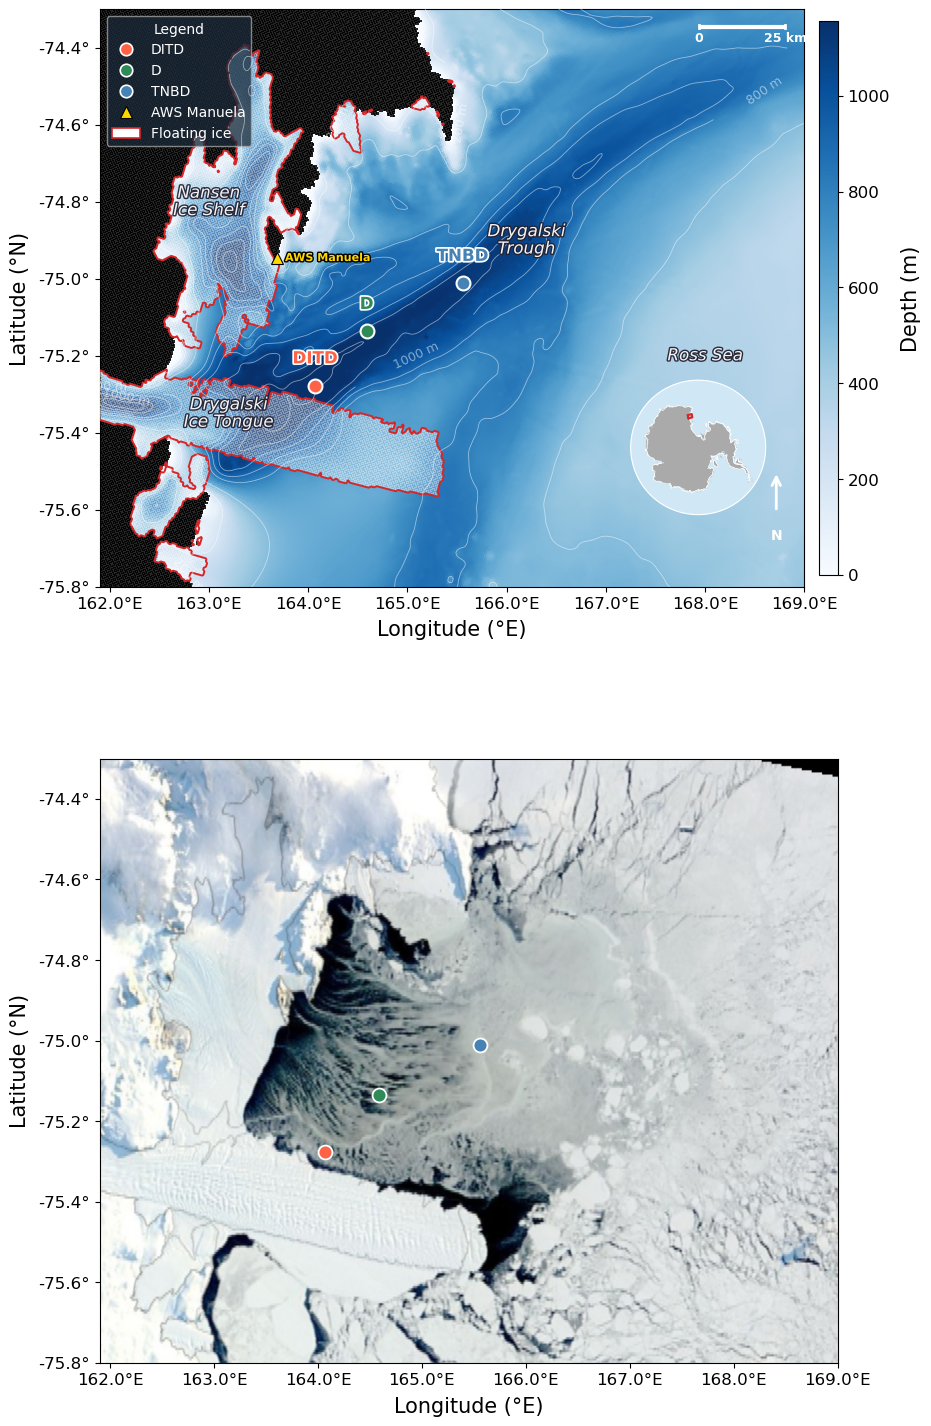

In [ ]:
import numpy as np
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter
from pyproj import Transformer
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath

plt.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 14,
    'axes.titlesize': 10,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 10,
})
FIGSIZE = (9, 16)   # ← portrait, full-page: width ~ \textwidth, tall enough for 2 stacked square-ish panels

# ── USER INPUTS ───────────────────────────────────────────────────────────────
MOORINGS = {
    'DITD': {
        'lon':    float(DITD_ctd_top.lon.values),
        'lat':    float(DITD_ctd_top.lat.values),
        'color':  'tomato',
        'vel_ds': DITD_vel_top,
    },
    'D': {
        'lon':    float(D_vel_bot.lon.values),
        'lat':    float(D_vel_bot.lat.values),
        'color':  'seagreen',
        'vel_ds': D_vel_bot,
    },
    'TNBD': {
        'lon':    float(TNBD_vel_bot.lon.values),
        'lat':    float(TNBD_vel_bot.lat.values),
        'color':  'steelblue',
        'vel_ds': TNBD_vel_bot,
    },
}

AWS_MANUELA = {'lon': 163.687, 'lat': -74.946}

LON_BOUNDS     = (161.9, 169.0)
LAT_BOUNDS     = (-75.8, -74.3)
DEPTH_CONTOURS = [200, 500, 800, 900, 1000, 1100, 1200]
QUIVER_SCALE   = 0.07
ARROW_REF_SPEED = 0.05

SATELLITE_TIF = "/Users/mblan/Downloads/snapshot-2018-03-23_TNB.tiff"

GEO_LABELS = [
    {'text': 'Drygalski\nIce Tongue', 'lon': 163.2,  'lat': -75.35,
     'size': 12,  'style': 'italic', 'color': 'white'},
    {'text': 'Nansen\nIce Shelf',     'lon': 163,  'lat': -74.8,
     'size': 12,  'style': 'italic', 'color': 'white'},
    {'text': 'Drygalski\nTrough',     'lon': 166.2,  'lat': -74.9,
     'size': 12,  'style': 'italic', 'color': 'white'},
    {'text': 'Ross Sea',              'lon': 168,  'lat': -75.2,
     'size': 12,  'style': 'italic', 'color': 'white'},
]

lat_mean  = np.mean(LAT_BOUNDS)
lat_scale = 1.0 / np.cos(np.deg2rad(lat_mean))

# ── LOAD BEDMACHINE ───────────────────────────────────────────────────────────
transformer_inv = Transformer.from_crs('EPSG:3031', 'EPSG:4326',
                                        always_xy=True)
x_2d, y_2d     = np.meshgrid(bath['x'].values, bath['y'].values)
lon_2d, lat_2d = transformer_inv.transform(x_2d, y_2d)

bed  = bath['bed'].values.astype(float)
mask = bath['mask'].values

depth_raw  = np.where(bed < 0, -bed, np.nan)
ocean_mask = (mask == 0) | (mask == 3)
depth_plot = np.where(ocean_mask, depth_raw, np.nan)
depth_sm   = gaussian_filter(np.where(ocean_mask, depth_raw, 0), sigma=2)
depth_sm   = np.where(ocean_mask, depth_sm, np.nan)

in_bounds      = ((lon_2d >= LON_BOUNDS[0]) & (lon_2d <= LON_BOUNDS[1]) &
                   (lat_2d >= LAT_BOUNDS[0]) & (lat_2d <= LAT_BOUNDS[1]))
depth_inbounds = depth_plot[in_bounds & np.isfinite(depth_plot)]
vmax           = np.nanpercentile(depth_inbounds, 98) \
                 if depth_inbounds.size > 0 else 2000

# ── FIGURE: TWO PANELS, STACKED (2 rows, 1 column) ─────────────────────────────
fig, (ax, ax_sat) = plt.subplots(2, 1, figsize=FIGSIZE)
fig.patch.set_facecolor('white')

# ═══════════════════════════════════════════════════════════════════════════
# TOP PANEL — satellite image
# ═══════════════════════════════════════════════════════════════════════════
with rasterio.open(SATELLITE_TIF) as src:
    sat_img = src.read()
    sat_bounds = src.bounds
    sat_crs = src.crs
    if sat_crs is not None and sat_crs.to_epsg() != 4326:
        from rasterio.warp import calculate_default_transform, reproject, Resampling
        dst_crs = 'EPSG:4326'
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        sat_img_reproj = np.empty((src.count, height, width), dtype=src.dtypes[0])
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=sat_img_reproj[i - 1],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear)
        sat_img = sat_img_reproj
        sat_extent = [transform[2], transform[2] + transform[0] * width,
                      transform[5] + transform[4] * height, transform[5]]
    else:
        sat_extent = [sat_bounds.left, sat_bounds.right,
                      sat_bounds.bottom, sat_bounds.top]

sat_display = np.transpose(sat_img[:3], (1, 2, 0))
if sat_display.dtype != np.uint8:
    sat_display = sat_display.astype(float)
    p2, p98 = np.nanpercentile(sat_display, (2, 98))
    sat_display = np.clip((sat_display - p2) / (p98 - p2), 0, 1)

ax_sat.imshow(sat_display, extent=sat_extent, origin='upper', zorder=1)

ax_sat.set_xlim(LON_BOUNDS)
ax_sat.set_ylim(LAT_BOUNDS)
ax_sat.set_aspect(lat_scale)
ax_sat.set_xlabel('Longitude (°E)', fontsize=15, labelpad=6)
ax_sat.set_ylabel('Latitude (°N)',  fontsize=15, labelpad=6)
ax_sat.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}°E'))
ax_sat.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f'{y:.1f}°'))
ax_sat.tick_params(labelsize=12)

for name, props in MOORINGS.items():
    ax_sat.plot(props['lon'], props['lat'],
                marker='o', markersize=10, color=props['color'],
                markeredgecolor='white', markeredgewidth=1.3,
                linestyle='none', zorder=9)

# ═══════════════════════════════════════════════════════════════════════════
# BOTTOM PANEL — bathymetry / mooring map
# ═══════════════════════════════════════════════════════════════════════════
pcm = ax.pcolormesh(lon_2d, lat_2d, depth_plot,
                     cmap='Blues', shading='auto',
                     vmin=0, vmax=vmax, zorder=1)
cbar = plt.colorbar(pcm, ax=ax, pad=0.02, fraction=0.025, aspect=30)
cbar.set_label('Depth (m)', fontsize=15, labelpad=8)
cbar.ax.tick_params(labelsize=12)

land = np.where((mask == 1) | (mask == 2), 1.0, np.nan)
ax.pcolormesh(lon_2d, lat_2d, land,
              cmap='Greys', shading='auto',
              vmin=0, vmax=1, alpha=0.85, zorder=2)

floating_white = np.where(mask == 3, 1.0, np.nan)
ax.pcolormesh(lon_2d, lat_2d, floating_white,
              cmap='Greys_r', shading='auto',
              vmin=0, vmax=1, alpha=0.3, zorder=3)

ax.contour(lon_2d, lat_2d, (mask == 3).astype(float),
           levels=[0.5],
           colors=['tab:red'],
           linewidths=1.4,
           linestyles='-',
           zorder=5)

valid_contours = [c for c in DEPTH_CONTOURS
                  if np.nanmin(depth_sm) < c < np.nanmax(depth_sm)]
if valid_contours:
    cs = ax.contour(lon_2d, lat_2d, depth_sm,
                     levels=valid_contours,
                     colors='white', linewidths=0.6,
                     alpha=0.5, zorder=6)
    ax.clabel(cs, levels=valid_contours[::2], fmt='%d m',
              fontsize=9, colors='white', inline=True,
              inline_spacing=4)

for lbl in GEO_LABELS:
    t = ax.text(lbl['lon'], lbl['lat'], lbl['text'],
                ha='center', va='center',
                fontsize=lbl['size'], style=lbl['style'],
                color=lbl['color'], zorder=7, alpha=0.95)
    t.set_path_effects([
        pe.withStroke(linewidth=2.0, foreground='#222233')])

for name, props in MOORINGS.items():
    ax.plot(props['lon'], props['lat'],
            marker='o', markersize=10, color=props['color'],
            markeredgecolor='white', markeredgewidth=1.5,
            linestyle='none', zorder=9)
    txt = ax.text(props['lon'], props['lat'] + 0.05, name,
                  ha='center', va='bottom', fontsize=12,
                  fontweight='bold', color=props['color'], zorder=9)
    txt.set_path_effects([
        pe.withStroke(linewidth=2.5, foreground='white')])

ax.plot(AWS_MANUELA['lon'], AWS_MANUELA['lat'],
        marker='^', markersize=9, color='gold',
        markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=9,
        label='AWS Manuela')
txt = ax.text(AWS_MANUELA['lon'] + 0.08, AWS_MANUELA['lat'],
              'AWS Manuela',
              ha='left', va='center', fontsize=8,
              color='gold', fontweight='bold', zorder=10)
txt.set_path_effects([pe.withStroke(linewidth=2.0, foreground='k')])

ax.annotate('', xy=(0.96, 0.20), xytext=(0.96, 0.13),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='white',
                            lw=2.0, mutation_scale=15))
ax.text(0.96, 0.10, 'N', transform=ax.transAxes,
        ha='center', va='top', fontsize=10,
        color='white', fontweight='bold')

ice_patch = mpatches.Patch(facecolor='white', edgecolor='tab:red',
                            linewidth=1.2, label='Floating ice')
aws_handle = plt.Line2D([0], [0], marker='^', color='none',
                         markerfacecolor='gold', markeredgecolor='k',
                         markeredgewidth=0.8, markersize=9,
                         label='AWS Manuela')
mooring_handles = [
    plt.Line2D([0], [0], marker='o', color='none',
               markerfacecolor=p['color'],
               markeredgecolor='white',
               markeredgewidth=1.2,
               markersize=9, label=n)
    for n, p in MOORINGS.items()
]

leg = ax.legend(handles=mooring_handles + [aws_handle, ice_patch],
                loc='upper left', fontsize=10,
                framealpha=0.75, edgecolor='#aaaaaa',
                facecolor='#1a2a3a', labelcolor='white',
                title='Legend', title_fontsize=10)
leg.get_title().set_color('white')

ax.set_aspect(lat_scale)
ax.set_xlim(LON_BOUNDS)
ax.set_ylim(LAT_BOUNDS)
ax.set_xlabel('Longitude (°E)', fontsize=15, labelpad=6)
ax.set_ylabel('Latitude (°N)',  fontsize=15, labelpad=6)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}°E'))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f'{y:.1f}°'))
ax.tick_params(labelsize=12)

R          = 6371.0
km_per_deg = R * np.cos(np.deg2rad(lat_mean)) * np.pi / 180.0
bar_deg    = 25 / km_per_deg
xlim, ylim = ax.get_xlim(), ax.get_ylim()

sb_x = xlim[1] - 0.15 * (xlim[1] - xlim[0])
sb_y = ylim[1] - 0.03 * (ylim[1] - ylim[0])

ax.plot([sb_x, sb_x + bar_deg], [sb_y, sb_y],
        color='white', lw=3, solid_capstyle='butt', zorder=12)
for xpt in [sb_x, sb_x + bar_deg]:
    ax.plot([xpt, xpt], [sb_y - 0.004, sb_y + 0.004],
            color='white', lw=2, zorder=12)
ax.text(sb_x,             sb_y - 0.012, '0',
        ha='center', va='top', fontsize=9,
        color='white', fontweight='bold', zorder=12)
ax.text(sb_x + bar_deg,   sb_y - 0.012, '25 km',
        ha='center', va='top', fontsize=9,
        color='white', fontweight='bold', zorder=12)

# ── INSET MAP — repositioned for stacked layout (upper-right of bottom panel) ─
ax_inset = fig.add_axes([0.69, 0.6, 0.15, 0.10],
                          projection=ccrs.SouthPolarStereo(central_longitude=180))
ax_inset.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax_inset.add_feature(cfeature.LAND,  facecolor='#aaaaaa', zorder=1)
ax_inset.add_feature(cfeature.OCEAN, facecolor='#d0e8f5', zorder=0)
ax_inset.coastlines(resolution='110m', color='white',
                    linewidth=0.6, zorder=2)

study_lons = [LON_BOUNDS[0], LON_BOUNDS[1],
              LON_BOUNDS[1], LON_BOUNDS[0], LON_BOUNDS[0]]
study_lats = [LAT_BOUNDS[0], LAT_BOUNDS[0],
              LAT_BOUNDS[1], LAT_BOUNDS[1], LAT_BOUNDS[0]]
ax_inset.plot(study_lons, study_lats,
              color='tab:red', lw=1.5,
              transform=ccrs.PlateCarree(), zorder=3)
ax_inset.fill(study_lons, study_lats,
              color='tab:red', alpha=0.3,
              transform=ccrs.PlateCarree(), zorder=3)

theta  = np.linspace(0, 2 * np.pi, 100)
center = [0.5, 0.5]
radius = 0.5
verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax_inset.set_boundary(circle, transform=ax_inset.transAxes)

for spine in ax_inset.spines.values():
    spine.set_edgecolor('white')
    spine.set_linewidth(0.8)

plt.subplots_adjust(left=0.10, right=0.92, top=0.96, bottom=0.05, hspace=0.1)
# plt.savefig('study_site_two_panel_stacked.pdf', bbox_inches='tight', facecolor='white')
# plt.savefig('study_site_two_panel.png', dpi=400, bbox_inches='tight', facecolor='white')
plt.show()

### T/S Diagram Zoomed out 

In [48]:
# load in CTD data to add to TS diagram 
pipers = xr.open_dataset('data/pipers_ctd_58stations.nc')
# pipers = xr.open_dataset('data/PIPERS_ctd_DrygalskiBasin.nc')

In [51]:
palmer = xr.open_dataset('data/Palmer_CTD_41stations.nc')

In [52]:
palmer

<xarray.Dataset> Size: 20MB
Dimensions:                   (station: 41, sample: 1522)
Coordinates:
  * station                   (station) int64 328B 22 23 24 25 ... 77 78 79 80
    lat                       (station) float64 328B ...
    lon                       (station) float64 328B ...
  * sample                    (sample) int64 12kB 0 1 2 3 ... 1519 1520 1521
Data variables: (12/27)
    Date                      (station, sample) <U10 2MB ...
    Julian_Day                (station, sample) float64 499kB ...
    ISO_DateTime_UTC          (station, sample) <U20 5MB ...
    Pressure                  (station, sample) float64 499kB ...
    Depth                     (station, sample) float64 499kB ...
    Temperature               (station, sample) float64 499kB ...
    ...                        ...
    Scans_bin                 (station, sample) float64 499kB ...
    Flag                      (station, sample) float64 499kB ...
    Absolute_Salinity         (station, sample) float64 499kB ...
    Potential_Temperature     (station, sample) float64 499kB ...
    Conservative_Temperature  (station, sample) float64 499kB ...
    Potential_Density         (station, sample) float64 499kB ...

In [49]:
pipers

<xarray.Dataset> Size: 35MB
Dimensions:                   (station: 58, sample: 3918)
Coordinates:
  * station                   (station) int64 464B 1 2 3 4 5 ... 54 55 56 57 58
    lat                       (station) float64 464B ...
    lon                       (station) float64 464B ...
    time                      (station) datetime64[ns] 464B ...
  * sample                    (sample) int64 31kB 1 2 3 4 ... 3916 3917 3918
    press                     (station, sample) float64 2MB ...
Data variables: (12/18)
    depth                     (station, sample) float64 2MB ...
    temp                      (station, sample) float64 2MB ...
    cond                      (station, sample) float64 2MB ...
    O2                        (station, sample) float64 2MB ...
    theta                     (station, sample) float64 2MB ...
    sal                       (station, sample) float64 2MB ...
    ...                        ...
    FLBB2                     (station, sample) float64 2MB ...
    Absolute_Salinity         (station, sample) float64 2MB ...
    Potential_Temperature     (station, sample) float64 2MB ...
    Conservative_Temperature  (station, sample) float64 2MB ...
    Potential_Density         (station, sample) float64 2MB ...
    N2                        (station, sample) float64 2MB ...
Attributes:
    source_file:  nbp1704_01d.txt
    year:         2017

In [43]:
pipers

<xarray.Dataset> Size: 6MB
Dimensions:                   (station: 10, sample: 3918)
Coordinates:
  * station                   (station) int64 80B 29 26 30 31 27 28 24 32 25 33
    lat                       (station) float64 80B ...
    lon                       (station) float64 80B ...
    time                      (station) datetime64[ns] 80B ...
  * sample                    (sample) int64 31kB 1 2 3 4 ... 3916 3917 3918
    press                     (station, sample) float64 313kB ...
Data variables: (12/18)
    depth                     (station, sample) float64 313kB ...
    temp                      (station, sample) float64 313kB ...
    cond                      (station, sample) float64 313kB ...
    O2                        (station, sample) float64 313kB ...
    theta                     (station, sample) float64 313kB ...
    sal                       (station, sample) float64 313kB ...
    ...                        ...
    FLBB2                     (station, sample) float64 313kB ...
    Absolute_Salinity         (station, sample) float64 313kB ...
    Potential_Temperature     (station, sample) float64 313kB ...
    Conservative_Temperature  (station, sample) float64 313kB ...
    Potential_Density         (station, sample) float64 313kB ...
    N2                        (station, sample) float64 313kB ...
Attributes:
    source_file:  nbp1704_01d.txt
    year:         2017

In [44]:
print(pipers)

<xarray.Dataset> Size: 6MB
Dimensions:                   (station: 10, sample: 3918)
Coordinates:
  * station                   (station) int64 80B 29 26 30 31 27 28 24 32 25 33
    lat                       (station) float64 80B ...
    lon                       (station) float64 80B ...
    time                      (station) datetime64[ns] 80B ...
  * sample                    (sample) int64 31kB 1 2 3 4 ... 3916 3917 3918
    press                     (station, sample) float64 313kB ...
Data variables: (12/18)
    depth                     (station, sample) float64 313kB ...
    temp                      (station, sample) float64 313kB ...
    cond                      (station, sample) float64 313kB ...
    O2                        (station, sample) float64 313kB ...
    theta                     (station, sample) float64 313kB ...
    sal                       (station, sample) float64 313kB ...
    ...                        ...
    FLBB2                     (station, sample) f

In [39]:
import numpy as np
import gsw
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patheffects as pe

def TS_template(ax, mint, maxt, mins, maxs, lon=165, lat=-75.0112, p=1093,
                n_levels=6, freezing_p=0, manual_labels=None):
    """
    Draws sigma-theta density contours and the surface freezing line on ax.
    Generalized from your original so it can be reused at different zoom
    levels (overview panel vs. per-mooring zoomed panels).
    """
    tempL = np.linspace(mint, maxt, 200)
    salL  = np.linspace(mins, maxs, 200)
    Tg, Sg = np.meshgrid(tempL, salL)

    SA = gsw.SA_from_SP(Sg, p, lon, lat)
    CT = gsw.CT_from_pt(SA, Tg)
    sigma_theta = gsw.sigma0(SA, CT)

    t_freezing = gsw.t_freezing(gsw.SA_from_SP(salL, freezing_p, lon, lat),
                                  p=freezing_p, saturation_fraction=0)
    ax.plot(salL, t_freezing, 'k--', linewidth=1, zorder=1,
            label='Surface freezing line')

    cs = ax.contour(Sg, Tg, sigma_theta, colors='grey', linewidths=0.8,
                     alpha=0.8, levels=n_levels, zorder=1)
    if manual_labels is not None:
        ax.clabel(cs, fontsize=8, inline=True, manual=manual_labels, fmt='%.2f')
    else:
        ax.clabel(cs, fontsize=8, inline=True, fmt='%.2f')

    ax.set_xlim(mins, maxs)
    ax.set_ylim(mint, maxt)
    return cs

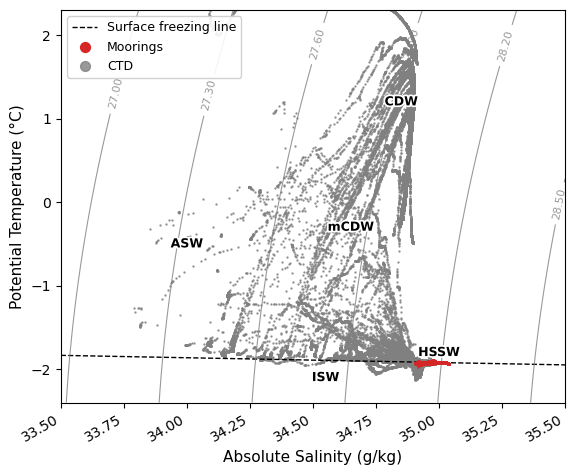

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(6, 5))

# ── T/S template (isopycnals, freezing line, etc.) ───────────────────────────
TS_template(ax, mint=-2.4, maxt=2.3, mins=33.5, maxs=35.5)

# ── Scatter data ──────────────────────────────────────────────────────────────
ax.scatter(TNBD_ctd_top.abs_sal, TNBD_ctd_top.theta,
           s=0.5, color='tab:red', label='Moorings')
ax.scatter(TNBD_ctd_bot.abs_sal, TNBD_ctd_bot.theta,
           s=0.5, color='tab:red')

ax.scatter(DITD_ctd_top.abs_sal, DITD_ctd_top.theta,
           s=0.5, color='tab:red',)
ax.scatter(DITD_ctd_bot.abs_sal, DITD_ctd_bot.theta,
           s=0.5, color='tab:red')

ax.scatter(D_ctd_top.abs_sal, D_ctd_top.theta,
           s=0.5, color='tab:red',)
ax.scatter(D_ctd_mid.abs_sal, D_ctd_mid.theta,
           s=0.5, color='tab:red')

ax.scatter(pipers.Absolute_Salinity.values.flatten(),
           pipers.Potential_Temperature.values.flatten(),
           s=0.5, alpha=0.8, color='grey', label='CTD', zorder=0)

ax.scatter(palmer.Absolute_Salinity.values.flatten(),
           palmer.Potential_Temperature.values.flatten(),
           s=0.5, alpha=0.8, color='grey', zorder=0)

# ── Water mass labels ─────────────────────────────────────────────────────────
water_masses = {
    'ASW':  (34.0,   -0.5),
    'HSSW': (35.0,   -1.8),
    'ISW':  (34.55,  -2.1),
    'mCDW': (34.65,  -0.3),
    'CDW':  (34.85,   1.2),
}
for name, (s, t) in water_masses.items():
    ax.annotate(name, xy=(s, t), fontsize=9,
                fontweight='bold', color='k',
                ha='center', va='center',
                path_effects=[
                    pe.withStroke(linewidth=2.5, foreground='white')])

# ── Labels and formatting ─────────────────────────────────────────────────────
ax.set_xlabel('Absolute Salinity (g/kg)', fontsize=11)
ax.set_ylabel('Potential Temperature (°C)', fontsize=11)
# ax.set_title('All moorings', loc='left', fontsize=11, fontweight='bold')
ax.legend(markerscale=10, fontsize=9, loc='upper left', framealpha=0.9)
ax.tick_params(labelsize=10)

for label in ax.get_xticklabels():
    label.set_rotation(30)
    label.set_ha('right')

plt.tight_layout()
# plt.savefig('TS_diagram_all_moorings.png',
#             dpi=300, bbox_inches='tight', facecolor='white')
plt.show()